##  Hướng dẫn sử dụng

### Lần đầu chạy:
1. Chạy **Cell 1**: Import libraries
2. Chạy **Cell 2**: Mount Drive và kiểm tra files
   -  **QUAN TRỌNG**: Sửa `BASE_DIR` cho đúng với đường dẫn folder của bạn
   - Ví dụ: `BASE_DIR = "/content/drive/MyDrive/ML_Projects"`
   (ở đây tui dùng BASE_DIR = "/content/drive/MyDrive/input", nếu để nguyên vậy thì đỡ phải sửa đường dẫn hơn)
3. Chạy **Cell 3-16**: Thực hiện pipeline

### Lần sau:
Nếu đã có file `processed_data.npz` trong Drive, chỉ cần:
1. Chạy **Cell 1-2**: Setup
2. Chạy **Cell 15** hoặc **Cell 16**: Load dữ liệu đã xử lý


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 Phần 1: Setup (Cells 1-2)

- Import libraries
- Upload files hoặc download từ URL

In [5]:


## Cell 1: Import Libraries
import random
import struct
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import os

plt.style.use('default')
sns.set_palette("husl")

print(" Libraries imported successfully!")

from google.colab import drive

drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive"
input_path = os.path.join(BASE_DIR, "input")

training_images_filepath = os.path.join(input_path, "train-images.idx3-ubyte")
training_labels_filepath = os.path.join(input_path, "train-labels.idx1-ubyte")
test_images_filepath = os.path.join(input_path, "t10k-images.idx3-ubyte")
test_labels_filepath = os.path.join(input_path, "t10k-labels.idx1-ubyte")


required_files = [
    "train-images.idx3-ubyte",
    "train-labels.idx1-ubyte",
    "t10k-images.idx3-ubyte",
    "t10k-labels.idx1-ubyte"
]

all_exist = True
for filename in required_files:
    filepath = os.path.join(input_path, filename)
    exists = os.path.exists(filepath)
    status = "ok" if exists else "wrong"

    if exists:
        size = os.path.getsize(filepath) / (1024*1024)
        print(f"{status} {filename} ({size:.2f} MB)")
    else:
        print(f"{status} {filename} - NOT FOUND")
        all_exist = False

if all_exist:
    print("\n All files found.")
else:
    print("\n  Some files are missing. Please check your folder path.")
    print(f"Current path: {input_path}")
    print("\nTip: Update BASE_DIR in the code above to match your folder location.")


 Libraries imported successfully!
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ok train-images.idx3-ubyte (44.86 MB)
ok train-labels.idx1-ubyte (0.06 MB)
ok t10k-images.idx3-ubyte (7.48 MB)
ok t10k-labels.idx1-ubyte (0.01 MB)

 All files found.


#  Phần 2: Định nghĩa Functions (Cells 3-5)

- DataLoader class
- Utility functions (accuracy, confusion matrix, normalize, one-hot)
- EDA visualization functions

In [3]:
## Cell 3: MNIST DataLoader Class
class MnistDataloader(object):
    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images(self, filepath):
        with open(filepath, 'rb') as f:
            magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
            image_data = np.frombuffer(f.read(), dtype=np.uint8)
            images = image_data.reshape(num_images, rows, cols)
        return images

    def read_labels(self, filepath):
        with open(filepath, 'rb') as f:
            magic, num_labels = struct.unpack(">II", f.read(8))
            labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

    def load_data(self):
        x_train = self.read_images(self.training_images_filepath)
        y_train = self.read_labels(self.training_labels_filepath)
        x_test = self.read_images(self.test_images_filepath)
        y_test = self.read_labels(self.test_labels_filepath)
        return (x_train, y_train), (x_test, y_test)

print(" MnistDataloader class defined")


## Cell 4: Utility Functions
def accuracy(y_true, y_pred):
    """Calculate accuracy score"""
    return np.mean(y_true == y_pred)


def confusion_matrix(y_true, y_pred, num_classes=10):
    """Create confusion matrix"""
    cm = np.zeros((num_classes, num_classes), dtype=np.int32)
    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1
    return cm


def plot_confusion_matrix(cm, title='Confusion Matrix'):
    """Plot confusion matrix heatmap"""
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.title(title, fontsize=16)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()


def normalize_images(images):
    """Normalize pixel values to [0, 1]"""
    return images.astype(np.float32) / 255.0


def one_hot_encode(labels, num_classes=10):
    """Convert labels to one-hot encoding"""
    return np.eye(num_classes)[labels]

print(" Utility functions defined")

## Cell 5: EDA Visualization Functions

def plot_class_distribution(labels, title='Class Distribution'):
    """Plot distribution of classes"""
    counter = Counter(labels)
    classes = sorted(counter.keys())
    counts = [counter[c] for c in classes]

    plt.figure(figsize=(12, 6))
    plt.bar(classes, counts, color='steelblue', alpha=0.8)
    plt.xlabel('Digit Class', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.title(title, fontsize=14)
    plt.xticks(classes)
    plt.grid(axis='y', alpha=0.3)

    for i, (c, count) in enumerate(zip(classes, counts)):
        plt.text(c, count + 50, str(count), ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()


def plot_sample_images(images, labels, samples_per_class=10):
    """Plot sample images for each class"""
    fig, axes = plt.subplots(10, samples_per_class, figsize=(15, 18))
    fig.suptitle('Sample Images per Class', fontsize=16, y=0.995)

    for digit in range(10):
        indices = np.where(labels == digit)[0]
        sample_indices = np.random.choice(indices, samples_per_class, replace=False)

        for idx, sample_idx in enumerate(sample_indices):
            axes[digit, idx].imshow(images[sample_idx], cmap='gray')
            axes[digit, idx].axis('off')
            if idx == 0:
                axes[digit, idx].set_title(f'Digit {digit}', fontsize=12, loc='left')

    plt.tight_layout()
    plt.show()


def plot_pixel_statistics(images):
    """Plot pixel value statistics"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    mean_image = np.mean(images, axis=0)
    im1 = axes[0].imshow(mean_image, cmap='hot')
    axes[0].set_title('Mean Pixel Values Across Dataset', fontsize=12)
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0])

    std_image = np.std(images, axis=0)
    im2 = axes[1].imshow(std_image, cmap='hot')
    axes[1].set_title('Std Dev of Pixel Values', fontsize=12)
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1])

    pixel_values = images.flatten()
    axes[2].hist(pixel_values, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[2].set_title('Distribution of Pixel Values', fontsize=12)
    axes[2].set_xlabel('Pixel Value', fontsize=10)
    axes[2].set_ylabel('Frequency', fontsize=10)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print(" EDA visualization functions defined")



 MnistDataloader class defined
 Utility functions defined
 EDA visualization functions defined


 Phần 3: EDA (Cells 6-9)

- Load data
- Phân tích phân bố class
- Hiển thị sample images
- Thống kê pixel

LOADING MNIST DATA

 Data loaded successfully!
   Training set: (60000, 28, 28), Labels: (60000,)
   Test set: (10000, 28, 28), Labels: (10000,)
   Image shape: (28, 28)
   Pixel value range: [0, 255]
   Number of classes: 10
 Class Distribution Analysis
----------------------------------------


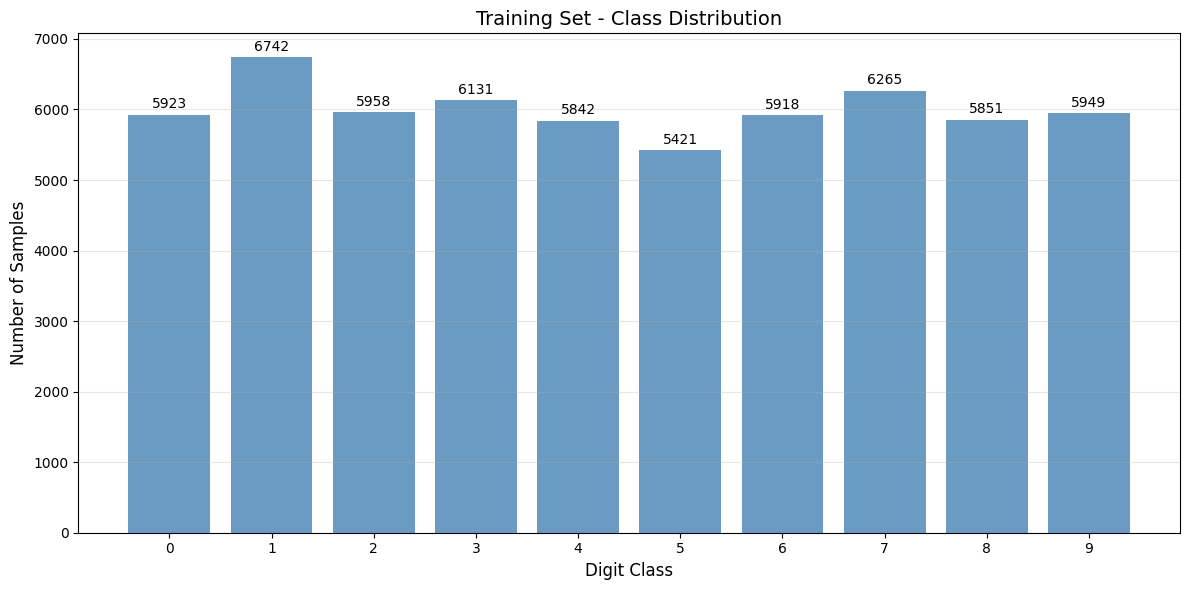

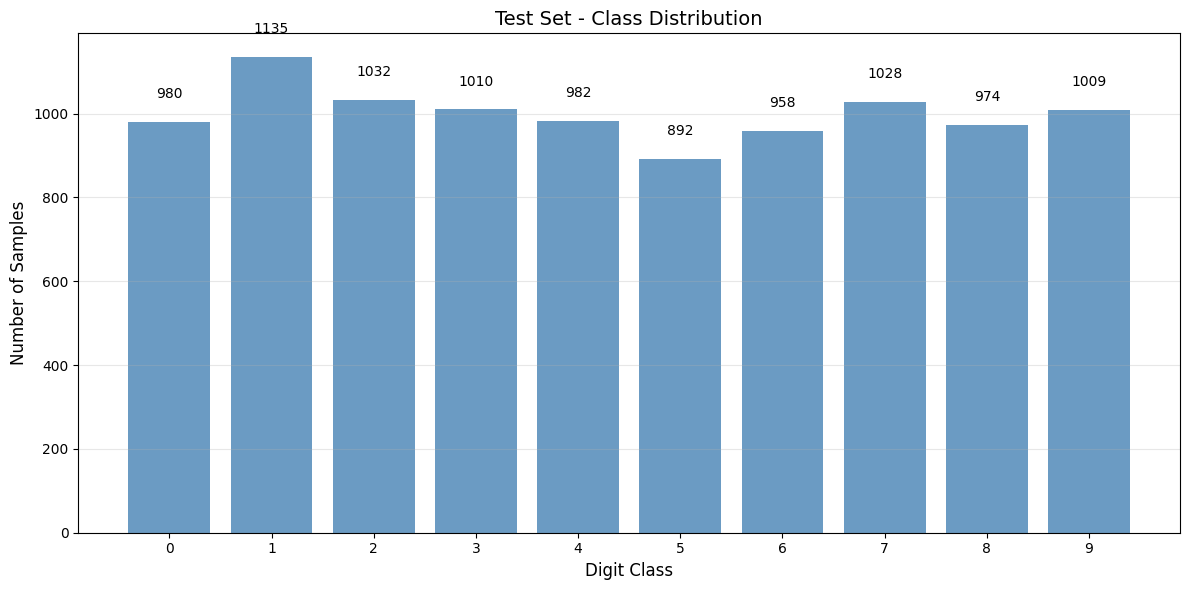

 Sample Images per Class
----------------------------------------


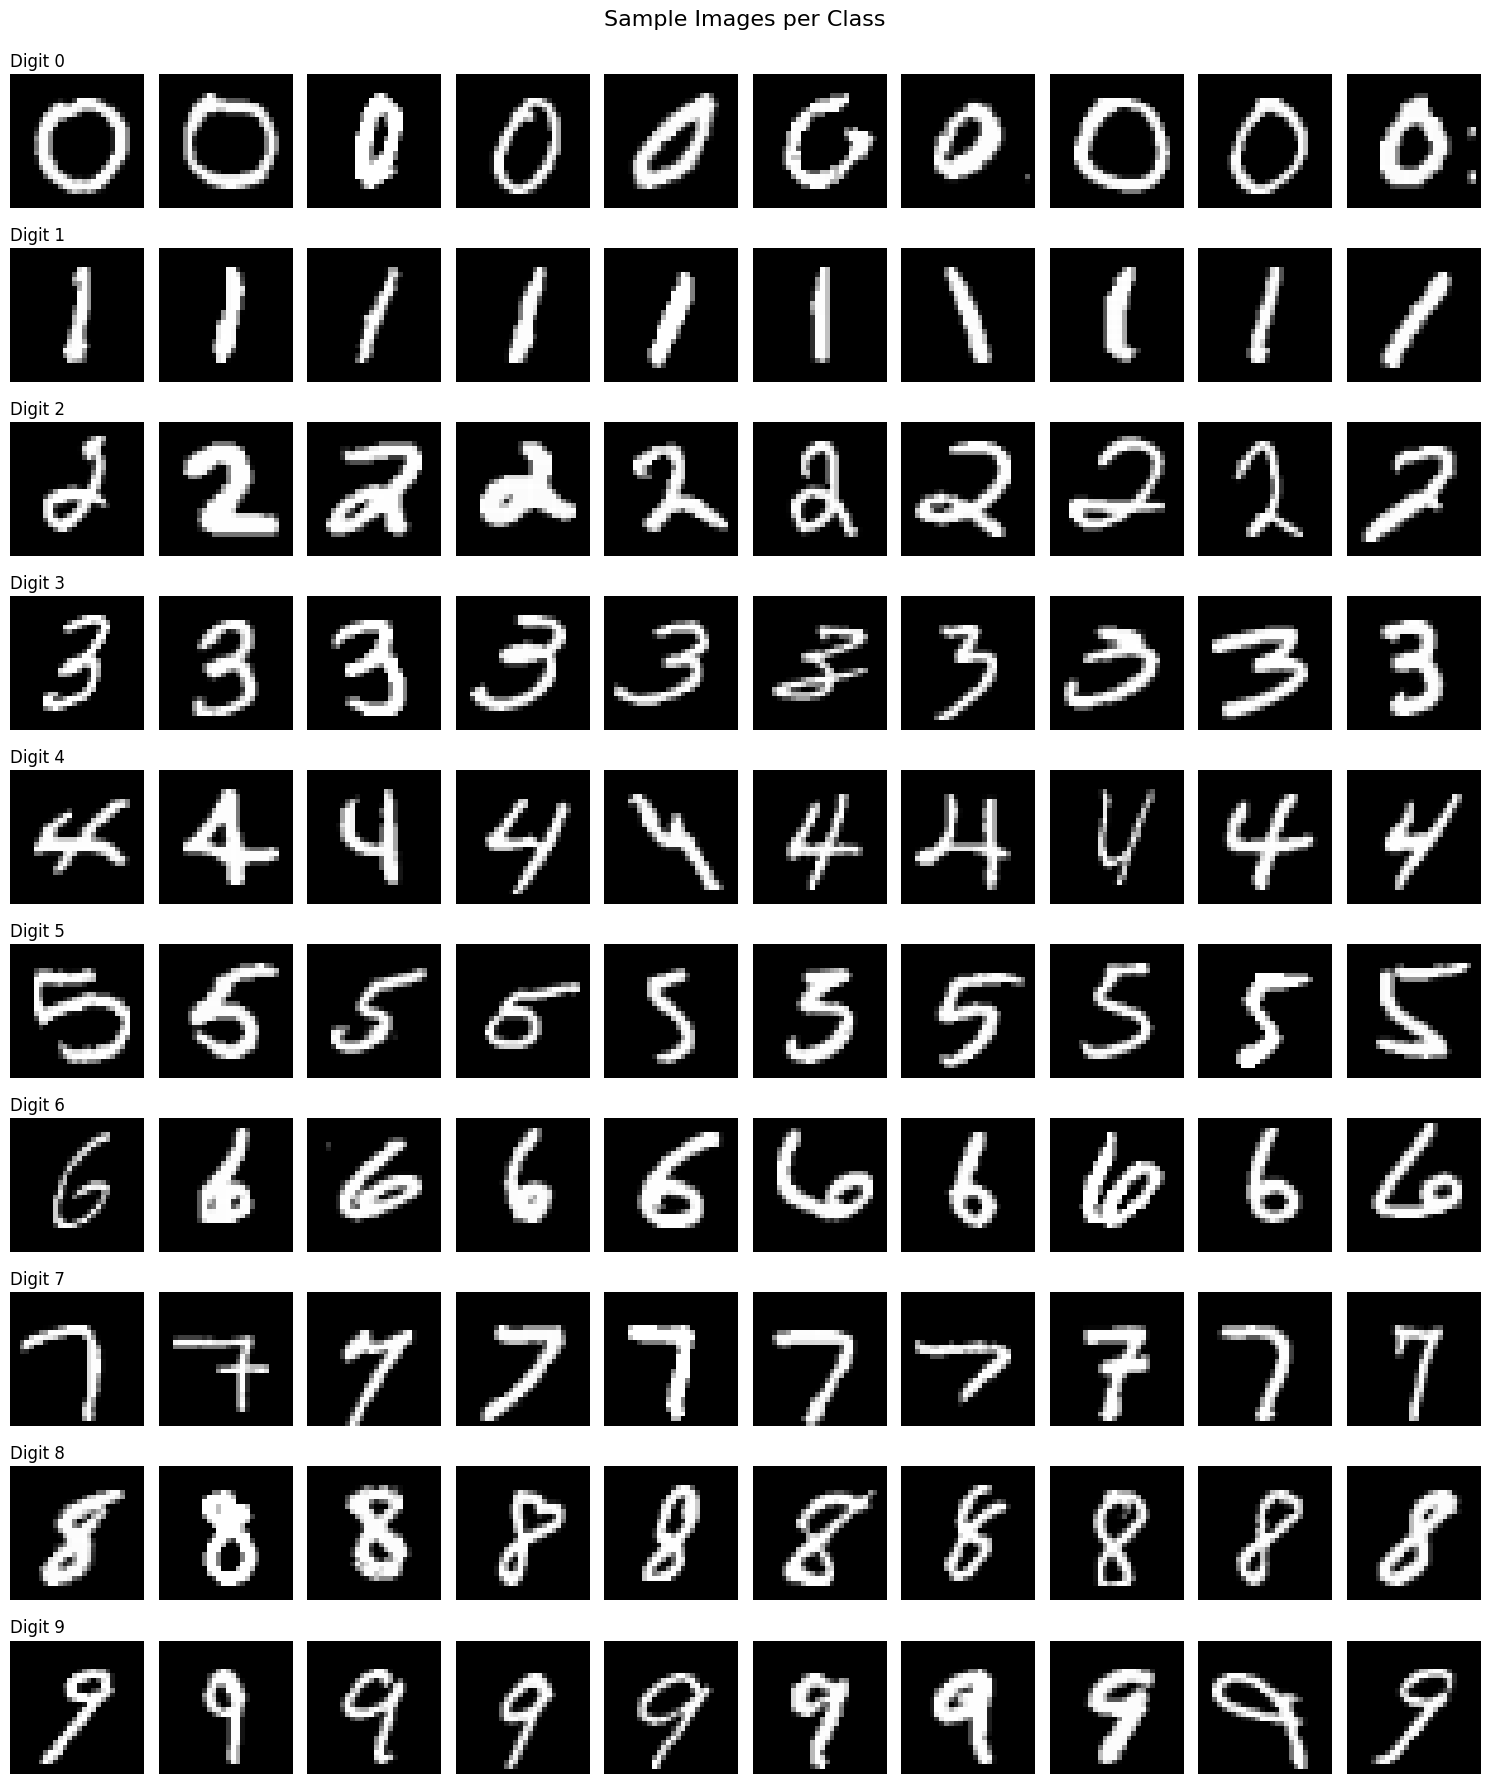

 Pixel Statistics Analysis
----------------------------------------


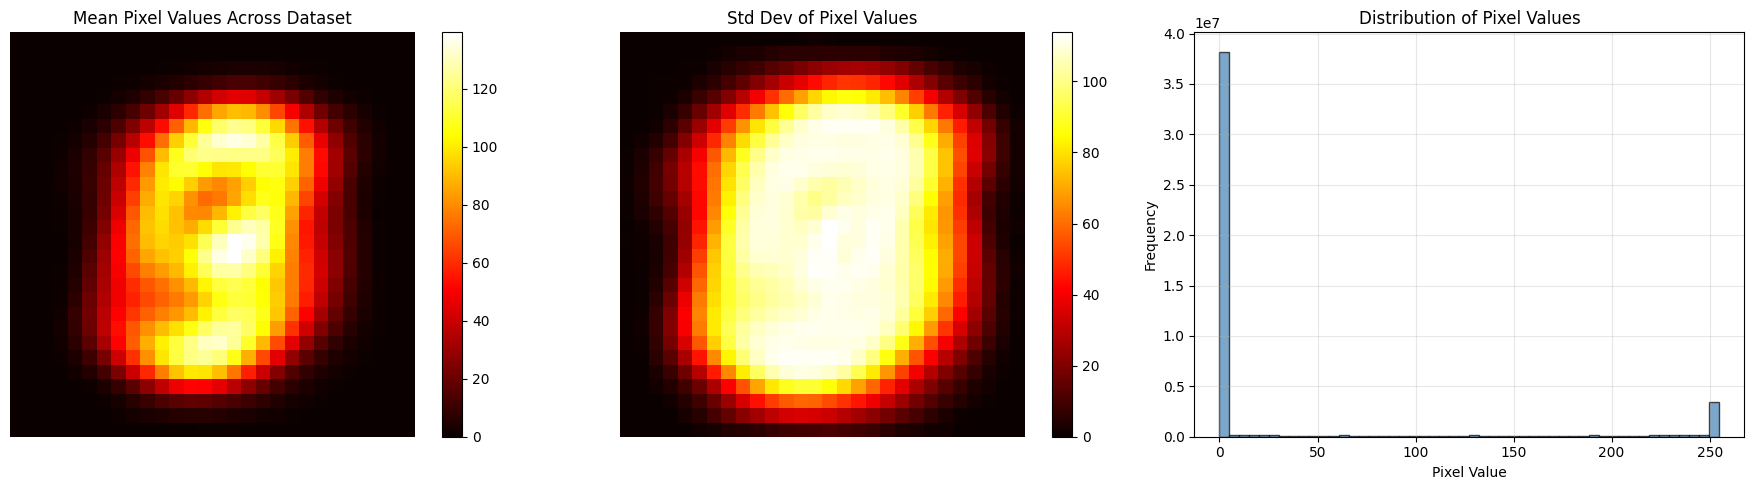

In [4]:
## Cell 6: Load MNIST Data
print("=" * 60)
print("LOADING MNIST DATA")
print("=" * 60)

mnist_dataloader = MnistDataloader(
    training_images_filepath,
    training_labels_filepath,
    test_images_filepath,
    test_labels_filepath
)

(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

print(f"\n Data loaded")
print(f"   Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"   Test set: {x_test.shape}, Labels: {y_test.shape}")
print(f"   Image shape: {x_train[0].shape}")
print(f"   Pixel value range: [{x_train.min()}, {x_train.max()}]")
print(f"   Number of classes: {len(np.unique(y_train))}")


## Cell 7: EDA - Class Distribution
print(" Class Distribution Analysis")
print("-" * 40)

plot_class_distribution(y_train, 'Training Set - Class Distribution')
plot_class_distribution(y_test, 'Test Set - Class Distribution')


## Cell 8: EDA - Sample Images

print(" Sample Images per Class")
print("-" * 40)

plot_sample_images(x_train, y_train, samples_per_class=10)


## Cell 9: EDA - Pixel Statistics
print(" Pixel Statistics Analysis")
print("-" * 40)

plot_pixel_statistics(x_train)


 Phần 4: Preprocessing (Cells 10-12)

- Normalization
- One-hot encoding
- Data splitting (50k/10k/10k)

PREPROCESSING

1. Normalizing images to [0, 1]...
    Normalized pixel range: [0.000, 1.000]

2. One-hot encoding labels...
    One-hot shape: (60000, 10)
   Example: Label 5 → [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
DATA SPLITTING

 Data split completed:
   Training:   (50000, 28, 28)
   Validation: (10000, 28, 28)
   Test:       (10000, 28, 28)
VERIFYING CLASS DISTRIBUTION

Class    Train      Val        Test      
----------------------------------------
0        4952       971        980       
1        5583       1159       1135      
2        4942       1016       1032      
3        5172       959        1010      
4        4888       954        982       
5        4524       897        892       
6        4899       1019       958       
7        5227       1038       1028      
8        4846       1005       974       
9        4967       982        1009      


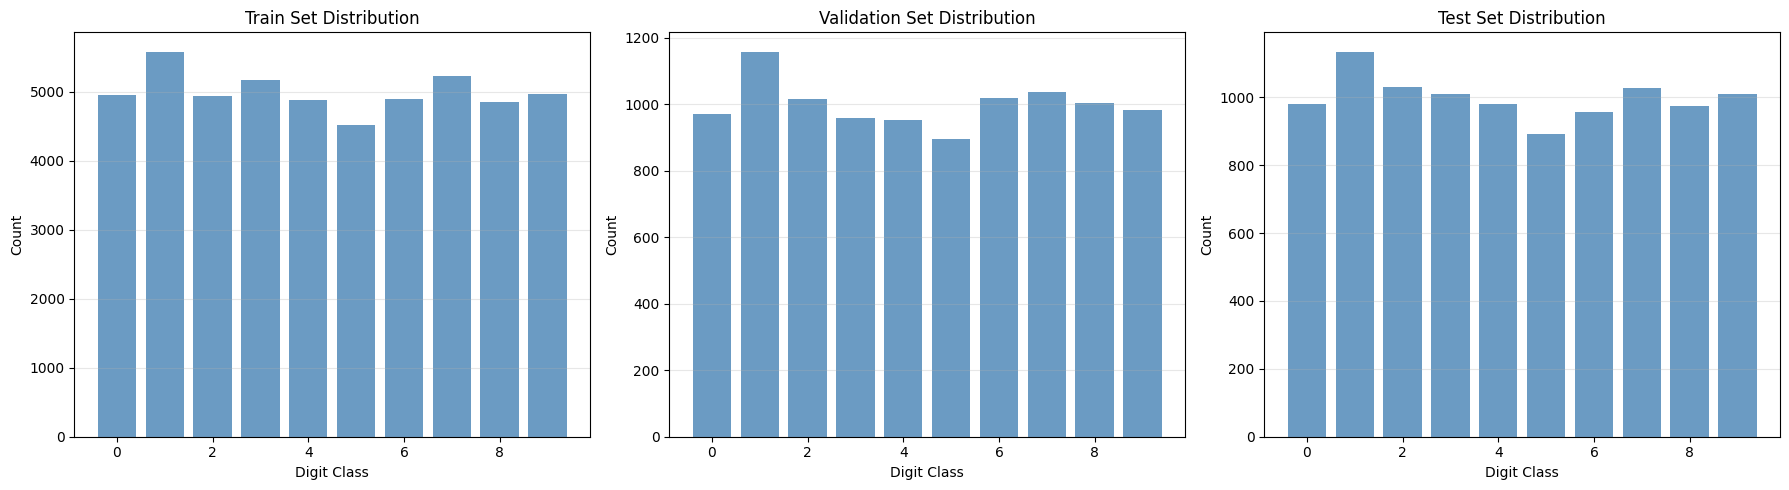

In [9]:
## Cell 10: Preprocessing - Normalization & One-Hot Encoding

print("PREPROCESSING")

print("\n1. Normalizing images to [0, 1]...")
x_train_norm = normalize_images(x_train)
x_test_norm = normalize_images(x_test)
print(f"    Normalized pixel range: [{x_train_norm.min():.3f}, {x_train_norm.max():.3f}]")

print("\n2. One-hot encoding labels...")
y_train_onehot = one_hot_encode(y_train)
y_test_onehot = one_hot_encode(y_test)
print(f"    One-hot shape: {y_train_onehot.shape}")
print(f"   Example: Label {y_train[0]} → {y_train_onehot[0]}")




## Cell 11: Data Splitting (50k Train / 10k Val / 10k Test)
print("DATA SPLITTING")

np.random.seed(42)
indices = np.random.permutation(len(x_train_norm))

train_indices = indices[:50000]
val_indices = indices[50000:60000]

x_train_final = x_train_norm[train_indices]
y_train_final = y_train[train_indices]
y_train_final_onehot = y_train_onehot[train_indices]

x_val = x_train_norm[val_indices]
y_val = y_train[val_indices]
y_val_onehot = y_train_onehot[val_indices]

x_test_final = x_test_norm
y_test_final = y_test
y_test_final_onehot = y_test_onehot

print(f"\n Data split completed:")
print(f"   Training:   {x_train_final.shape}")
print(f"   Validation: {x_val.shape}")
print(f"   Test:       {x_test_final.shape}")

## Cell 12: Verify Class Distribution in Splits
print("VERIFYING CLASS DISTRIBUTION")

train_dist = Counter(y_train_final)
val_dist = Counter(y_val)
test_dist = Counter(y_test_final)

print(f"\n{'Class':<8} {'Train':<10} {'Val':<10} {'Test':<10}")
print("-" * 40)
for digit in range(10):
    print(f"{digit:<8} {train_dist[digit]:<10} {val_dist[digit]:<10} {test_dist[digit]:<10}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (dist, title) in zip(axes, [
    (train_dist, 'Train'),
    (val_dist, 'Validation'),
    (test_dist, 'Test')
]):
    classes = sorted(dist.keys())
    counts = [dist[c] for c in classes]
    ax.bar(classes, counts, color='steelblue', alpha=0.8)
    ax.set_xlabel('Digit Class')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} Set Distribution')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


 Phần 5: Validation & Export (Cells 13-16)

- Test utilities
- Save file .npz
- Load & verify
- Download file

TESTING UTILITY FUNCTIONS

 Accuracy function: 0.0920
 Confusion matrix shape: (10, 10)

Confusion Matrix Sample (first 5x5):
[[ 8 15 13  9  9]
 [13 15  8 13  9]
 [ 9 13 13 14  5]
 [ 9 11  6  6 13]
 [10  9  9  9 10]]


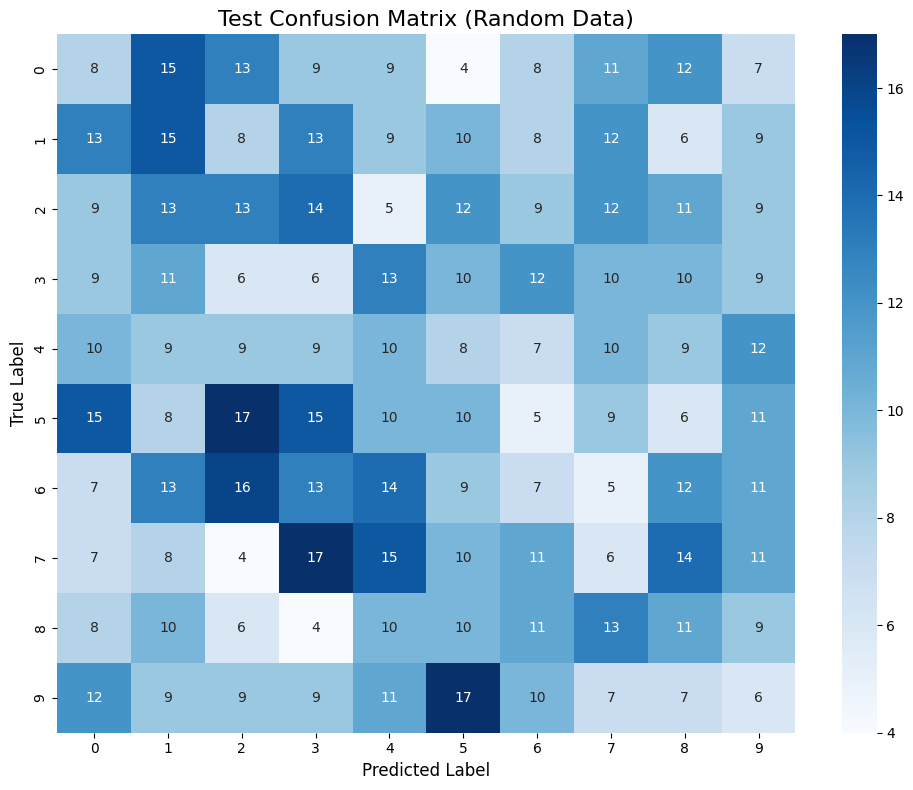

SAVING PROCESSED DATA
 Saving to: /content/drive/MyDrive/processed_data.npz

 Data saved successfully!
Testing data loading from Google Drive

 Available keys: ['x_train', 'y_train', 'y_train_onehot', 'x_val', 'y_val', 'y_val_onehot', 'x_test', 'y_test', 'y_test_onehot']

Shapes:
  x_train: (50000, 28, 28)
  y_train: (50000,)
  y_train_onehot: (50000, 10)
  x_val: (10000, 28, 28)
  y_val: (10000,)
  y_val_onehot: (10000, 10)
  x_test: (10000, 28, 28)
  y_test: (10000,)
  y_test_onehot: (10000, 10)


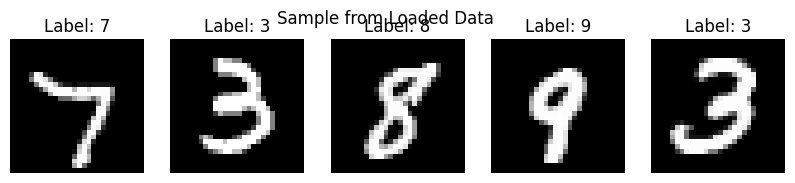


 Data loaded.


In [14]:
## Cell 13: Test Utility Functions
print("TESTING UTILITY FUNCTIONS")

dummy_pred = np.random.randint(0, 10, size=1000)
dummy_true = np.random.randint(0, 10, size=1000)

acc = accuracy(dummy_true, dummy_pred)
cm = confusion_matrix(dummy_true, dummy_pred)

print(f"\n Accuracy function: {acc:.4f}")
print(f" Confusion matrix shape: {cm.shape}")
print("\nConfusion Matrix Sample (first 5x5):")
print(cm[:5, :5])

plot_confusion_matrix(cm, 'Test Confusion Matrix (Random Data)')


## Cell 14: Save Processed Data to Google Drive
print("SAVING PROCESSED DATA")

output_path = os.path.join(BASE_DIR, "processed_data.npz")

print(f" Saving to: {output_path}")

np.savez_compressed(
    output_path,
    x_train=x_train_final,
    y_train=y_train_final,
    y_train_onehot=y_train_final_onehot,
    x_val=x_val,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    x_test=x_test_final,
    y_test=y_test_final,
    y_test_onehot=y_test_final_onehot
)

print(f"\n Data saved successfully!")


## Cell 15: Load & Verify Saved Data (Optional)
# Test loading the saved data
print("Testing data loading from Google Drive")

data_path = os.path.join(BASE_DIR, "processed_data.npz")
data = np.load(data_path)

print("\n Available keys:", list(data.keys()))
print(f"\nShapes:")
print(f"  x_train: {data['x_train'].shape}")
print(f"  y_train: {data['y_train'].shape}")
print(f"  y_train_onehot: {data['y_train_onehot'].shape}")
print(f"  x_val: {data['x_val'].shape}")
print(f"  y_val: {data['y_val'].shape}")
print(f"  y_val_onehot: {data['y_val_onehot'].shape}")
print(f"  x_test: {data['x_test'].shape}")
print(f"  y_test: {data['y_test'].shape}")
print(f"  y_test_onehot: {data['y_test_onehot'].shape}")

# Display sample
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(data['x_train'][i], cmap='gray')
    plt.title(f"Label: {data['y_train'][i]}")
    plt.axis('off')
plt.suptitle('Sample from Loaded Data')
plt.show()

print("\n Data loaded.")



## Cell 16: Quick Load Function (Bonus)
def load_processed_mnist(base_dir="/content/drive/MyDrive"):
    """
    Quick function to load processed MNIST data

    Usage:
        x_train, y_train, y_train_oh, x_val, y_val, y_val_oh, x_test, y_test, y_test_oh = load_processed_mnist()
    """
    data_path = os.path.join(base_dir, "processed_data.npz")

    if not os.path.exists(data_path):
        raise FileNotFoundError(f"File not found: {data_path}")

    data = np.load(data_path)

    return (
        data['x_train'], data['y_train'], data['y_train_onehot'],
        data['x_val'], data['y_val'], data['y_val_onehot'],
        data['x_test'], data['y_test'], data['y_test_onehot']
    )


